<a id = '0'></a>
<h2 style = "font-family: garamond; font-size: 40px; font-style: normal; letter-spcaing: 3px; background-color: #007580; color : #fed049; border-radius: 5px 5px; text-align:center; font-weight: bold" >Table of Contents</h2> 

1. [Overview](#1.0)
2. [Import the necessary libraries](#2.0)
3. [Data Collection](#3.0)
4. [Feature Engineering](#4.0)
	- [VGG Face model](#4.1)
	- [Generate embeddings for each image in the dataset](#4.2)
	- [Plot images and get distance between the pairs](#4.3)
	- [Create train and test sets](#4.4)
	- [Reduce dimensions using PCA](#4.5)
5. [Model Building and Validation](#5.0)
    - [Build a Machine Learning Classifier](#5.1)
    - [Validate Celebrity Images](#5.2)
6. [Conclusion](#6.0)

<a id = '1.0'></a>
<h2 style = "font-size:35px; font-family:Garamond ; font-weight : normal; background-color: #007580; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> 1. Overview </h2> 

### Objective:

In this problem, we use a pre-trained model trained on Face recognition to recognize similar faces. Here, we are particularly interested in recognizing whether two given faces are of the same person or not.

<a id = '2.0'></a>
<h2 style = "font-size:35px; font-family:Garamond ; font-weight : normal; background-color: #007580; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> 2. Import the necessary libraries </h2> 

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# used to supress display of warnings
import warnings

from sklearn.metrics import precision_recall_curve,accuracy_score,f1_score,precision_score,recall_score

#### Setting Options

In [2]:
# suppress display of warnings
warnings.filterwarnings('ignore')

<a id = '3.0'></a>
<h2 style = "font-size:35px; font-family:Garamond ; font-weight : normal; background-color: #007580; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> 3. Data Collection </h2> 

In [3]:
import os
source_dir=os.path.join('6_classes_pins_dataset')

<p style = "font-size:20px; color: #007580 "><strong> Function to load images </strong></p> 
- Define a function to load the images from the extracted folder and map each image with person id 


In [4]:
class IdentityMetadata():
    def __init__(self, base, name, file):
        self.base = base
        # identity name
        self.name = name
        # image file name
        self.file = file

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.base, self.name, self.file) 
    
def load_metadata(path):
    metadata = []
    for i in os.listdir(path):
        for f in os.listdir(os.path.join(path, i)):
            # Check file extension. Allow only jpg/jpeg' files.
            ext = os.path.splitext(f)[1]
            if ext == '.jpg' or ext == '.jpeg':
                metadata.append(IdentityMetadata(path, i, f))
    return np.array(metadata)

# metadata = load_metadata('images')
metadata = load_metadata(source_dir)

In [5]:
np.save('metadata_6', metadata)

In [6]:
print('metadata shape :', metadata.shape)

metadata shape : (937,)


In [7]:
type(metadata[100]), metadata[100].image_path()

(__main__.IdentityMetadata,
 '6_classes_pins_dataset/pins_Brenton Thwaites/Brenton Thwaites81_919.jpg')

<p style = "font-size:20px; color: #007580 "><strong> Define a function to load an image </strong></p>
- Define a function to load image from the metadata

In [8]:
import cv2
def load_image(path):
    img = cv2.imread(path, 1)
    # OpenCV loads images with color channels
    # in BGR order. So we need to reverse them
    return img[...,::-1]

<p style = "font-size:20px; color: #007580 "><strong> Load a sample image</strong></p>
- Load one image using the function "load_image"

In [9]:
# load_image('105_classes_pins_dataset/pins_Emilia Clarke/Emilia Clarke247_998.jpg')

<a id = '4.0'></a>
<h2 style = "font-size:35px; font-family:Garamond ; font-weight : normal; background-color: #007580; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> 4. Feature Engineering </h2> 

<a id = '4.1'></a>
<p style = "font-size:20px; color: #007580 "><strong> 4.1 VGG Face model </strong></p>
- Here we are giving you the predefined model for VGG face

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ZeroPadding2D, Convolution2D, MaxPooling2D, Dropout, Flatten, Activation

def vgg_face():	
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model

2023-04-01 16:15:50.424900: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-01 16:15:50.664656: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-01 16:15:50.703137: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/sarank21/.local/lib/python3.10/site-packages/cv2/../../lib64:
2023-04-01 16:1

<p style = "font-size:20px; color: #007580 "><strong> Load the model </strong></p>

- Load the model defined above
- Then load the given weight file named "vgg_face_weights.h5"

In [11]:
model = vgg_face()

model.load_weights('vgg_face_weights.h5')

2023-04-01 16:15:52.968161: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/sarank21/.local/lib/python3.10/site-packages/cv2/../../lib64:
2023-04-01 16:15:52.968393: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2023-04-01 16:15:52.968421: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (Nick): /proc/driver/nvidia/version does not exist
2023-04-01 16:15:52.968965: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the a

<p style = "font-size:20px; color: #007580 "><strong> Get vgg_face_descriptor </strong></p>

In [12]:
model.layers[0], model.layers[-2]

(<keras.layers.reshaping.zero_padding2d.ZeroPadding2D at 0x7f6499f22a10>,
 <keras.layers.reshaping.flatten.Flatten at 0x7f64541eea40>)

In [13]:
from tensorflow.keras.models import Model
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

In [14]:
type(vgg_face_descriptor)

keras.engine.functional.Functional

In [15]:
vgg_face_descriptor.inputs, vgg_face_descriptor.outputs

([<KerasTensor: shape=(None, 224, 224, 3) dtype=float32 (created by layer 'zero_padding2d_input')>],
 [<KerasTensor: shape=(None, 2622) dtype=float32 (created by layer 'flatten')>])

<a id = '4.2'></a>
<p style = "font-size:20px; color: #007580 "><strong> 4.2 Generate embeddings for each image in the dataset </strong></p>

- Given below is an example to load the first image in the metadata and get its embedding vector from the pre-trained model. 

In [16]:
# Get embedding vector for first image in the metadata using the pre-trained model
img_path = metadata[0].image_path()
img = load_image(img_path)

# Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]
img = (img / 255.).astype(np.float32)
img = cv2.resize(img, dsize = (224,224))
print(img.shape)

# Obtain embedding vector for an image
# Get the embedding vector for the above image using vgg_face_descriptor model and print the shape 
embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
print(embedding_vector)
print(embedding_vector.shape)

(224, 224, 3)
1/1 [==============================] - 1s 711ms/step
[ 0.01916374 -0.00984622 -0.01031522 ... -0.01343945  0.00268836
  0.02250816]
(2622,)


<p style = "font-size:20px; color: #007580 "><strong> Generate embeddings for all images </strong></p>

- Write code to iterate through metadata and create embeddings for each image using `vgg_face_descriptor.predict()` and store in a list with name `embeddings`

- If there is any error in reading any image in the dataset, fill the emebdding vector of that image with 2622-zeroes as the final embedding from the model is of length 2622.

In [17]:
total_images = len(metadata)

print('total_images :', total_images)

total_images : 937


In [18]:
# embeddings = np.zeros((metadata.shape[0], 2622))
# for i, m in enumerate(metadata):
#     img_path = metadata[i].image_path()
#     img = load_image(img_path)
#     img = (img / 255.).astype(np.float32)
#     img = cv2.resize(img, dsize = (224,224))
#     embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
#     embeddings[i]=embedding_vector

1/1 [==============================] - 0s 466ms/step


In [19]:
# print('embeddings shape :', embeddings.shape)

embeddings shape : (937, 2622)


In [20]:
# np.save('numpy docs/embeddings_6class.npy', embeddings)

In [21]:
embeddings = np.load('numpy docs/embeddings_6class.npy')

<p style = "font-size:20px; color: #007580 "><strong> Function to calculate distance between given 2 pairs of images </strong></p>

- Consider distance metric as "Squared L2 distance"
- Squared l2 distance between 2 points (x1, y1) and (x2, y2) = (x1-x2)^2 + (y1-y2)^2

In [22]:
def distance(emb1, emb2):
    return np.sum(np.square(emb1 - emb2))

<a id = '4.3'></a>
<p style = "font-size:20px; color: #007580 "><strong> 4.3 Plot images and get distance between the pairs </strong></p>

- 900, 901 and 900, 1001
- 1100, 1101 and 1100, 1300
- 1407, 1408 and 1408, 1602

In [23]:
def show_pair(idx1, idx2):
    plt.figure(figsize=(8,3))
    plt.suptitle(f'Distance between {idx1} & {idx2}= {distance(embeddings[idx1], embeddings[idx2]):.2f}')
    plt.subplot(121)
    plt.imshow(load_image(metadata[idx1].image_path()))
    plt.subplot(122)
    plt.imshow(load_image(metadata[idx2].image_path()));    

# show_pair(100, 101)
# show_pair(50, 151)

<a id = '4.4'></a>
<p style = "font-size:20px; color: #007580 "><strong> 4.4 Create train and test sets </strong></p>
- Create X_train, X_test and y_train, y_test
- Use train_idx to seperate out training features and labels
- Use test_idx to seperate out testing features and labels

In [24]:
train_idx = np.arange(metadata.shape[0]) % 6 != 0     #every 9th example goes in test data and rest go in train data
test_idx = np.arange(metadata.shape[0]) % 6 == 0
all_idx = np.arange(metadata.shape[0])

# one half as train examples of 10 identities
X_train = embeddings[train_idx]

# another half as test examples of 10 identities
X_test = embeddings[test_idx]

X_all = embeddings[all_idx]

targets = np.array([m.name for m in metadata])

#train labels
y_train = targets[train_idx]

#test labels
y_test = targets[test_idx]

y_all = targets[all_idx]

In [25]:
# np.save('numpy docs/X_all.npy', X_all)
# np.save('numpy docs/y_all.npy', y_all)

In [26]:
print('X_train shape : ({0},{1})'.format(X_train.shape[0], X_train.shape[1]))
print('y_train shape : ({0},)'.format(y_train.shape[0]))
print('X_test shape : ({0},{1})'.format(X_test.shape[0], X_test.shape[1]))
print('y_test shape : ({0},)'.format(y_test.shape[0]))

X_train shape : (780,2622)
y_train shape : (780,)
X_test shape : (157,2622)
y_test shape : (157,)


In [27]:
len(np.unique(y_test)), len(np.unique(y_train))

(6, 6)

<p style = "font-size:20px; color: #007580 "><strong> Encode the Labels </strong></p>
- Encode the targets
- Use LabelEncoder

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
targets_enc = le.fit_transform(targets)
# y_train_encoded = le.fit_transform(y_train)
# print(targets_enc)

In [29]:
print(le.classes_)
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
y_all_encoded = le.transform(y_all)

['pins_Bill Gates' 'pins_Bobby Morley' 'pins_Brenton Thwaites'
 'pins_Brian J. Smith' 'pins_Brie Larson' 'pins_barbara palvin']


In [51]:
# np.save('numpy docs/y_all_encoded', y_all_encoded)

<p style = "font-size:20px; color: #007580 "><strong> Standardize the feature values </strong></p> 
- Scale the features using StandardScaler

In [31]:
# Standarize features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
X_all_std = scaler.transform(X_all)

<a id = '4.5'></a>
<p style = "font-size:20px; color: #007580 "><strong> 4.5 Reduce dimensions using PCA </strong></p> 
- Reduce feature dimensions using Principal Component Analysis
- Set the parameter n_components=128

In [53]:
np.save('numpy docs/X_all_std.npy', X_all_std)
np.save('numpy docs/X_train_std.npy', X_train_std)

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=128)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
X_all_pca = pca.transform(X_all_std)

In [34]:
np.save('numpy docs/X_all_pca.npy', X_all_pca)

<a id = '5.1'></a>
<p style = "font-size:20px; color: #007580 "><strong> 5.1 Build a Machine Learning Classifier </strong></p> 

- Use SVM Classifier to predict the person in the given image
- Fit the classifier and print the score
- Use pickle to dump and load the trained model

In [35]:
from sklearn.svm import SVC
import pickle

clf = SVC(C=5., gamma=0.001, probability=True)
clf.fit(X_train_pca, y_train_encoded)

SVC(C=5.0, gamma=0.001, probability=True)

In [36]:
modelname = 'model1_6.sav'
pickle.dump(clf, open(modelname, 'wb'))

In [37]:
# clf = pickle.load(open(modelname, 'rb'))
y_predict = clf.predict(X_test_pca)

#### Calculating accuracy with Train Data and entire Data

In [38]:
np.save('numpy docs/exact_x.npy', X_all_pca)

In [39]:
y_predict_train = clf.predict(X_train_pca)
y_predict_all = clf.predict(X_all_pca)

In [40]:
print('y_predict : ',y_predict_all)
print('y_test_encoded : ',y_all_encoded)

y_predict :  [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 2 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5

In [41]:
y_predict_encoded = le.inverse_transform(y_predict)
y_predict_all_encoded = le.inverse_transform(y_predict_all)
y_predict_train_encoded = le.inverse_transform(y_predict_train)

In [42]:
# print('y_predict_encoded : ',y_predict_encoded)

In [43]:
print('y_predict shape : ', y_predict.shape)
print('y_test_encoded shape : ', y_test_encoded.shape)

y_predict shape :  (157,)
y_test_encoded shape :  (157,)


In [44]:
y_test_encoded[32:49]

array([2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [45]:
# Find the classification accuracy
print(accuracy_score(y_test_encoded, y_predict))
print(accuracy_score(y_train_encoded, y_predict_train))
print(accuracy_score(y_all_encoded, y_predict_all))

0.9936305732484076
1.0
0.9989327641408752


<a id = '5.2'></a>
<p style = "font-size:20px; color: #007580 "><strong> 5.2 Validate Celebrity Images </strong></p> 

- Take  104th  image from test set and plot the image
- Report to which person(folder name in dataset) the image belongs to

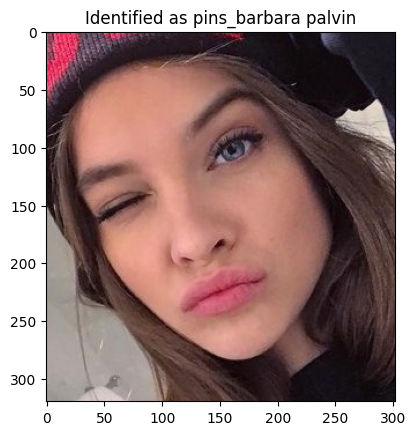

In [46]:
example_idx = 104

example_image = load_image(metadata[test_idx][example_idx].image_path())
example_prediction = y_predict[example_idx]
example_identity =  y_predict_encoded[example_idx]

plt.imshow(example_image)
plt.title(f'Identified as {example_identity}');

In [47]:
# metadata1 = load_metadata('Matt')
# embeddings1 = np.zeros((metadata1.shape[0], 2622))
# for i, m in enumerate(metadata1):
#     img_path = metadata1[i].image_path()
#     img = load_image(img_path)
#     img = (img / 255.).astype(np.float32)
#     img = cv2.resize(img, dsize = (224,224))
#     embedding_vector1 = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
#     embeddings1[i]=embedding_vector1


In [48]:
# ids = np.arange(metadata1.shape[0])
# print(metadata1.shape[0])
# imgs = embeddings1[ids]
# X_test_matt = scaler.fit_transform(imgs)

In [49]:
# pca = PCA(n_components=128)
# X_test_matt_pca = pca.fit_transform(X_test_matt)
# Y_predict_matt = clf.predict(X_test_matt_pca)

In [50]:
# y_predict_encoded1 = le.inverse_transform(Y_predict_matt)
# print(y_predict_encoded1)